# Simulações de Distribuições

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Distribuições - Normal, Poisson, Binomial Negativa, Exponencial

In [2]:
def resumo(amostra, nome):
    s = pd.Series(amostra)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    media, desvio = s.mean(), s.std()
    return pd.Series({
        "media": media,
        "mediana": s.median(),
        "desvio": desvio,
        "var/media": s.var() / media,
        "iqr": q3 - q1,
        "iqr/desvio": (q3 - q1) / desvio,
        "assimetria": s.skew(),
        "curtose": s.kurtosis(),
        "dentro_1_desvio": s.between(media - desvio, media + desvio).mean(),
    }, name=nome)

## Resumo - Estatisticas de cada distribuição

In [3]:
rng = np.random.default_rng(42)

casos = pd.read_csv("../data/raw/dengue_1-53.csv")["casos"]

# as quatro simuladas tem media ~50, pra comparacao ser de forma e nao de escala.
# na binomial negativa: media = n(1-p)/p  e  var/media = 1/p
amostras = {
    "normal": rng.normal(loc=50, scale=10, size=1000),
    "poisson": rng.poisson(lam=50, size=1000),
    "binomial_negativa": rng.negative_binomial(n=12.5, p=0.2, size=1000),
    "exponencial": rng.exponential(scale=50, size=1000),
    "casos": casos,
}

tabela_resumo = pd.DataFrame([resumo(a, nome) for nome, a in amostras.items()])
tabela_resumo

,media,mediana,desvio,var/media,iqr,iqr/desvio,assimetria,curtose,dentro_1_desvio
normal,49.711084,50.061779,9.892171,1.968475,12.861997,1.300220,-0.043754,0.091884,0.687000
poisson,49.831000,50.000000,7.231925,1.049562,10.000000,1.382758,0.109636,-0.215762,0.700000
binomial_negativa,50.538000,48.000000,15.480252,4.741743,20.250000,1.308118,0.595159,0.494706,0.694000
exponencial,49.798689,34.076147,49.717237,49.635918,52.722763,1.060452,1.824599,3.830648,0.857000
casos,48.635889,14.000000,92.129082,174.516555,37.000000,0.401610,3.283958,11.216078,0.912892


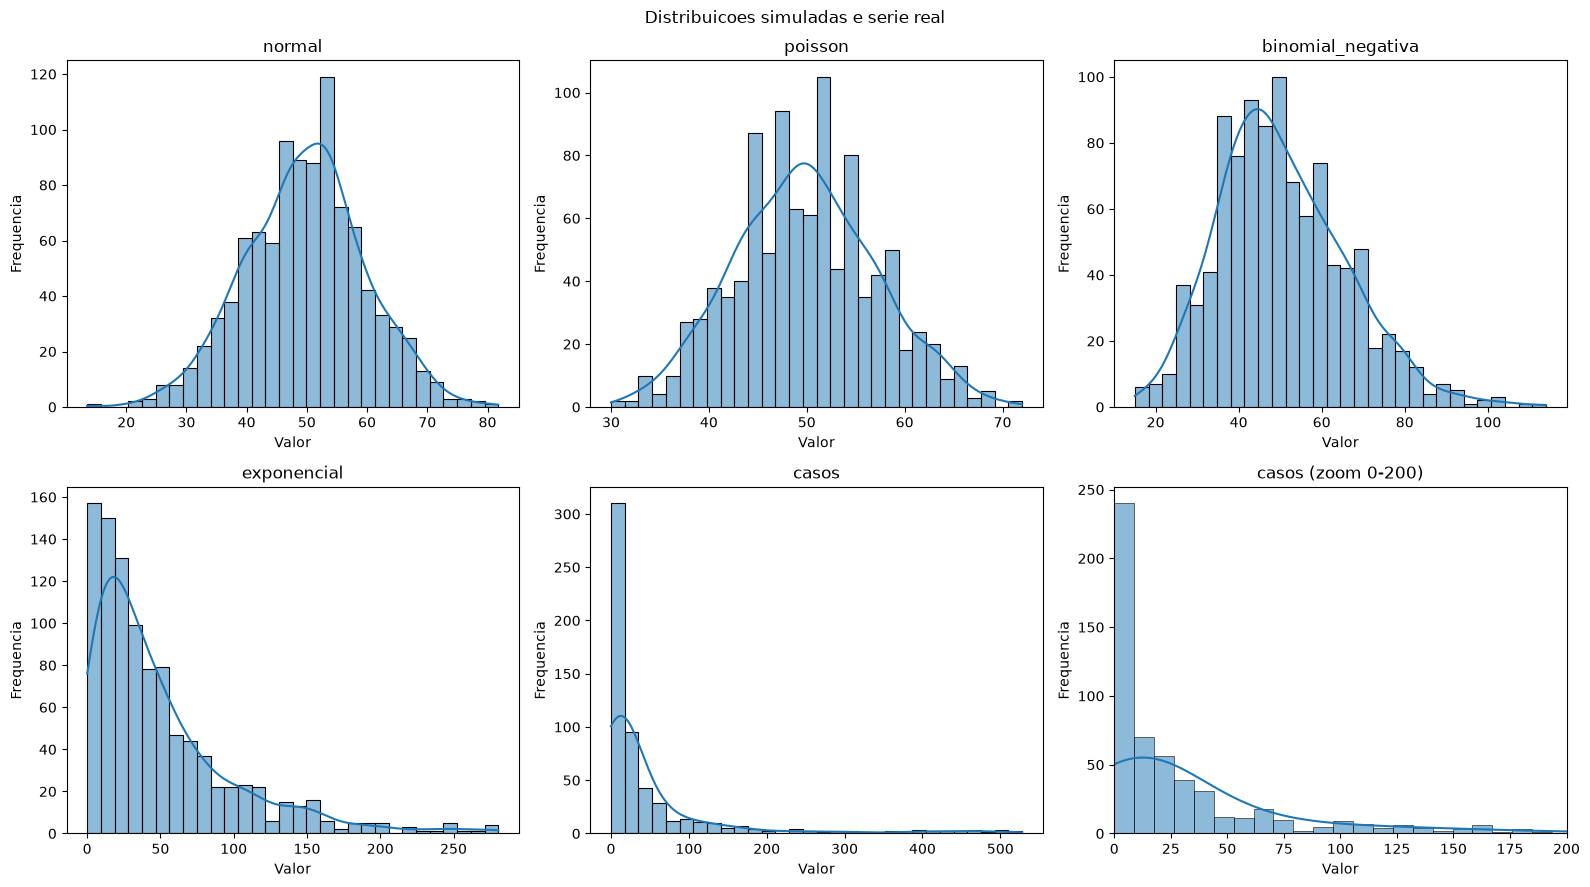

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (nome, amostra) in zip(axes.flat, amostras.items()):
    sns.histplot(amostra, kde=True, bins=30, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequencia")

# sexto painel: casos com a cauda cortada, pra enxergar o corpo da distribuicao
ax = axes.flat[5]
sns.histplot(casos, kde=True, bins="fd", ax=ax)
ax.set_xlim(0, 200)
ax.set_title("casos (zoom 0-200)")
ax.set_xlabel("Valor")
ax.set_ylabel("Frequencia")

plt.suptitle("Distribuicoes simuladas e serie real")
plt.tight_layout()
plt.show()

## Calibrando a binomial negativa contra a serie real

In [5]:
media_real = casos.mean()
dispersao_real = casos.var() / media_real

# var/media = 1/p        ->  p = 1 / dispersao
# media = n(1-p)/p       ->  n = media * p / (1-p)
p = 1 / dispersao_real
n = media_real * p / (1 - p)
print(f"dispersao medida em casos: {dispersao_real:.1f}")
print(f"p = {p:.5f}   n = {n:.4f}")

# mesmo tamanho da serie real, pro ruido amostral ser comparavel
nb_calibrada = rng.negative_binomial(n=n, p=p, size=len(casos))

pd.DataFrame([
    resumo(nb_calibrada, "binomial_negativa_calibrada"),
    resumo(casos, "casos"),
])

dispersao medida em casos: 174.5
p = 0.00573   n = 0.2803


,media,mediana,desvio,var/media,iqr,iqr/desvio,assimetria,curtose,dentro_1_desvio
binomial_negativa_calibrada,50.008711,12.0,95.469931,182.258403,53.0,0.555149,3.489254,15.106288,0.900697
casos,48.635889,14.0,92.129082,174.516555,37.0,0.401610,3.283958,11.216078,0.912892


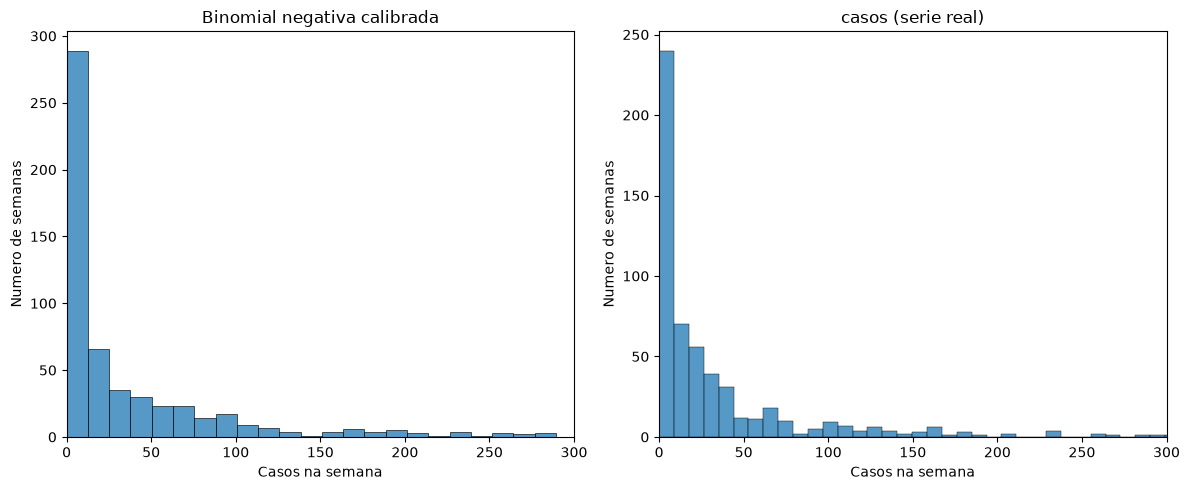

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

sns.histplot(nb_calibrada, bins="fd", ax=axes[0])
axes[0].set_title("Binomial negativa calibrada")

sns.histplot(casos, bins="fd", ax=axes[1])
axes[1].set_title("casos (serie real)")

for ax in axes:
    ax.set_xlim(0, 300)
    ax.set_xlabel("Casos na semana")
    ax.set_ylabel("Numero de semanas")

plt.tight_layout()
plt.show()

- Quais colunas a binomial negativa calibrada acerta, e quais ela erra?
   - média, mediana, desvio, assimetria e dentro_1_desvio
- Ela foi calibrada so com media e dispersao. Por que a assimetria e a mediana tambem chegam perto, se nao foram usadas no ajuste?
   - a binomial negativa tem dois parâmetros, então média e dispersão determinam o resto; a assimetria prevista (3,78) bate com a observada (3,28), o que é um teste da família e não um resultado do ajuste
    3,78 contra 3,28 não é coincidência exata. Parte da diferença é que a assimetria amostral é um estimador enviesado pra baixo quando a cauda é pesada e n=574 — nem toda a folga é erro do modelo.

    - A folga que sobra aparece no IQR (53 contra 37).
- O que essa distribuicao **nao** captura da serie real?
    - a binomial negativa descreve bem quanto os casos variam, mas trata as semanas como independentes — perde o piso endêmico (23,7% de zeros contra 1,9%) e, sobretudo, perde a estrutura temporal (autocorrelação 0,97), que é justamente o que o projeto quer explorar.
    